Load data

In [66]:
import pandas as pd
import numpy as np

df = pd.read_excel("water_quality.xlsx")

# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Vatsal\AppData\Local\Temp\ipykernel_24728\3821962350.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


Remove unnecessary columns

In [67]:
# Drop useless / non-informative columns
df.drop(["Year", "Station_Code", "Total_Coliform", "Fecal_Streptococci"], axis=1, inplace=True, errors='ignore')

Remove outliers

In [68]:
numeric_df = df.select_dtypes(include='number')

z_scores = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())
df = df[(z_scores < 3).all(axis=1)]

Create derived features

In [69]:
df["DO_BOD_ratio"] = df["DO"] / (df["BOD"] + 1)
df["Pollution_Index"] = df["BOD"] + df["Nitrate"] + df["Fecal_Coliform"] * 0.001
df["pH_deviation"] = abs(df["pH"] - 7)
df["Conductivity_log"] = np.log1p(df["Conductivity"])

CPCB Rule-Based Classification (BASELINE)

In [70]:
def cpcb_rule(row):
    if row["DO"] >= 6 and row["BOD"] <= 2 and row["Fecal_Coliform"] <= 50 and 6.5 <= row["pH"] <= 8.5:
        return 4
    elif row["DO"] >= 5 and row["BOD"] <= 3 and row["Fecal_Coliform"] <= 500 and 6.5 <= row["pH"] <= 8.5:
        return 3
    elif row["DO"] >= 4 and row["BOD"] <= 3 and row["Fecal_Coliform"] <= 5000 and 6.0 <= row["pH"] <= 9.0:
        return 2
    elif row["DO"] >= 4:
        return 1
    else:
        return 0

df["Rule_Label"] = df.apply(cpcb_rule, axis=1)

Adding noise

In [71]:
import random

def add_noise(label):
    if random.random() < 0.02:
        return random.randint(0, 4)
    return label

df["ML_Label"] = df["Rule_Label"].apply(add_noise)

In [72]:
df["Rule_Label_Feature"] = df["Rule_Label"]

Preparing data

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep only numeric
df = df.select_dtypes(include='number')

# ❌ REMOVE unwanted columns
df.drop(["ML_Prediction", "Rule_Label"], axis=1, inplace=True, errors='ignore')

# ✅ Keep Rule_Label_Feature only
X = df.drop(["ML_Label"], axis=1)
y = df["ML_Label"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
print("Final Features:", X.columns)
print("Total Features:", len(X.columns))

Final Features: Index(['Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate',
       'Fecal_Coliform', 'DO_BOD_ratio', 'Pollution_Index', 'pH_deviation',
       'Conductivity_log', 'Rule_Label_Feature'],
      dtype='object')
Total Features: 12


Training model

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(max_depth=15, n_estimators=300)
model.fit(X_train, y_train)

# Accuracy
print("Train:", model.score(X_train, y_train))
print("Test:", model.score(X_test, y_test))

# Cross-validation
scores = cross_val_score(model, X_scaled, y, cv=5)
print("CV:", scores.mean())

Train: 1.0
Test: 0.9857142857142858
CV: 0.8531150225133033


In [76]:
import joblib

# Save model + scaler
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

joblib.dump({
    "train": model.score(X_train, y_train),
    "test": model.score(X_test, y_test),
    "cv": scores.mean()
}, "metrics.pkl")

joblib.dump((X_test, y_test), "test_data.pkl")

['test_data.pkl']

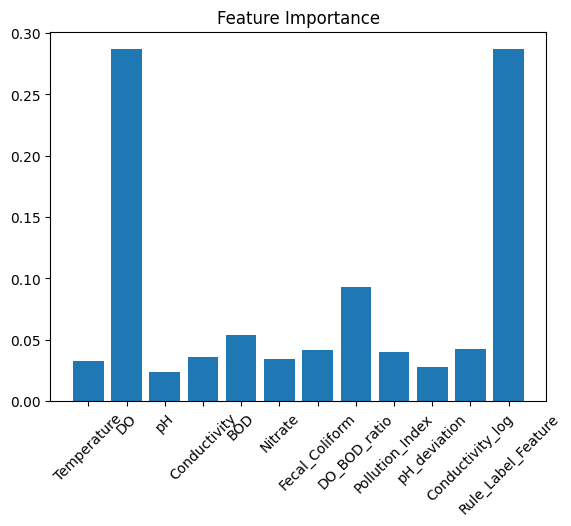

In [77]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

Saving model

In [78]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']